# Phase 3 — Baseline Evaluation

**Objective:** Rigorously evaluate the baseline spatial CNN using forensic-grade metrics. These results serve as the benchmark for all subsequent models. Accuracy alone is insufficient for forensic systems — this phase computes a full suite of metrics including specificity, sensitivity, and AUC-ROC.

## Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

2026-05-28 13:55:50.706090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779976551.216783      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779976551.348892      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779976552.528309      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779976552.528387      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779976552.528390      22 computation_placer.cc:177] computation placer alr

## Configuration & Paths

In [2]:
BASE_PATH   = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TEST_PATH   = os.path.join(BASE_PATH, "test")
MODEL_PATH  = "/kaggle/input/datasets/jasminsultanashimu/p-2-final-model/baseline_spatial_final.keras"
RESULT_DIR  = "/kaggle/working/results/baseline_spatial"

os.makedirs(RESULT_DIR, exist_ok=True)

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

## Load Model and Test Generator

`shuffle=False` is required so prediction order matches ground-truth label order.

In [3]:
model = load_model(MODEL_PATH)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices :", test_gen.class_indices)
print("Test samples  :", test_gen.samples)

I0000 00:00:1779976572.125578      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779976572.128489      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20000 images belonging to 2 classes.
Class indices : {'FAKE': 0, 'REAL': 1}
Test samples  : 20000


## Generate Predictions

Probability scores are produced first, then converted to binary predictions using a 0.5 threshold.

In [4]:
y_prob = model.predict(test_gen, verbose=1)
y_pred = (y_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

print("Predicted FAKE :", np.sum(y_pred == 1))
print("Predicted REAL :", np.sum(y_pred == 0))

I0000 00:00:1779976596.163062      67 service.cc:152] XLA service 0x7a2224047bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779976596.163102      67 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779976596.163105      67 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779976597.237577      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-28 13:56:44.486801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 13:56:44.620884: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 13:56:44.937718: E external/local_xl

625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 235ms/step
Predicted FAKE : 15465
Predicted REAL : 4535


## Compute Evaluation Metrics

Specificity (True Negative Rate) is calculated manually from the confusion matrix. In a forensic context it measures how well the model avoids falsely flagging genuine images.

In [5]:
accuracy    = accuracy_score(y_true, y_pred)
precision   = precision_score(y_true, y_pred)
recall      = recall_score(y_true, y_pred)
f1          = f1_score(y_true, y_pred)
auc_roc     = roc_auc_score(y_true, y_prob)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)

print("========== BASELINE EVALUATION ==========")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"Sensitivity : {recall:.4f}")
print(f"AUC-ROC     : {auc_roc:.4f}")
print("=========================================")

========== BASELINE EVALUATION ==========
Accuracy    : 0.6748
Precision   : 0.6131
Recall      : 0.9481
F1-Score    : 0.7446
Specificity : 0.4016
Sensitivity : 0.9481
AUC-ROC     : 0.8278


## Print Classification Report

In [6]:
label_names = [k for k, v in sorted(test_gen.class_indices.items(), key=lambda x: x[1])]
report      = classification_report(y_true, y_pred, target_names=label_names)

print(report)

with open(os.path.join(RESULT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

              precision    recall  f1-score   support

        FAKE       0.89      0.40      0.55     10000
        REAL       0.61      0.95      0.74     10000

    accuracy                           0.67     20000
   macro avg       0.75      0.67      0.65     20000
weighted avg       0.75      0.67      0.65     20000



## Confusion Matrix Heatmap

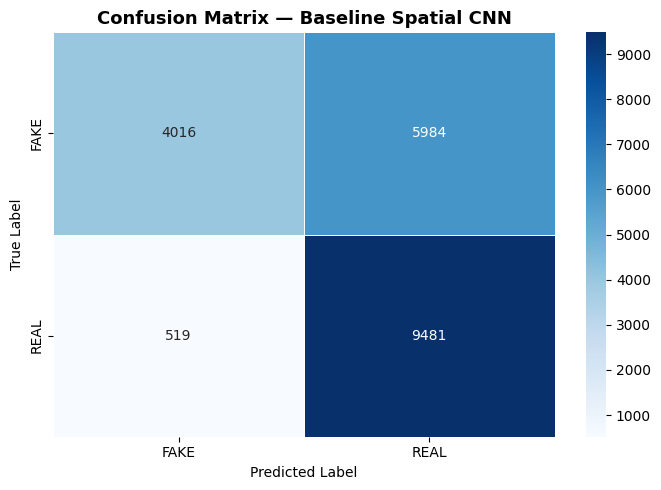

In [7]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names, yticklabels=label_names, linewidths=0.5
)
plt.title("Confusion Matrix — Baseline Spatial CNN", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## ROC Curve

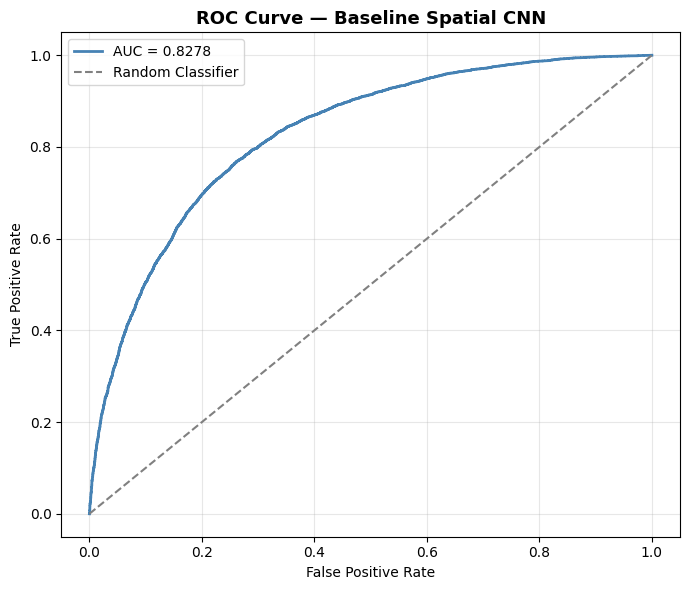

In [8]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_roc:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Spatial CNN", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save Evaluation Metrics to File

In [9]:
metrics_text = f"""========== BASELINE EVALUATION ==========

Accuracy    : {accuracy:.4f}
Precision   : {precision:.4f}
Recall      : {recall:.4f}
F1-Score    : {f1:.4f}
Specificity : {specificity:.4f}
Sensitivity : {recall:.4f}
AUC-ROC     : {auc_roc:.4f}

=========================================

Confusion Matrix:
  TP = {tp}   FN = {fn}
  FP = {fp}   TN = {tn}

Scientific Interpretation:
High recall (sensitivity) but low specificity indicates the model
is biased toward predicting FAKE. Real images are misclassified
at a near-random rate (specificity = {specificity:.4f}).

Spatial-only features from 32x32 source images are insufficient
for balanced detection. This motivates frequency-domain learning.
"""

with open(os.path.join(RESULT_DIR, "evaluation_metrics.txt"), "w") as f:
    f.write(metrics_text)

print(metrics_text)

========== BASELINE EVALUATION ==========

Accuracy    : 0.6748
Precision   : 0.6131
Recall      : 0.9481
F1-Score    : 0.7446
Specificity : 0.4016
Sensitivity : 0.9481
AUC-ROC     : 0.8278


Confusion Matrix:
  TP = 9481   FN = 519
  FP = 5984   TN = 4016

Scientific Interpretation:
High recall (sensitivity) but low specificity indicates the model
is biased toward predicting FAKE. Real images are misclassified
at a near-random rate (specificity = 0.4016).

Spatial-only features from 32x32 source images are insufficient
for balanced detection. This motivates frequency-domain learning.



---
## Phase 3 Complete

| Metric | Score |
|---|---|
| Accuracy | 0.6748 |
| Precision | 0.6131 |
| Recall | 0.9481 |
| F1-Score | 0.7446 |
| **Specificity** | **0.4016** ← critical weakness |
| AUC-ROC | 0.8272 |

**Key Finding:** Specificity of 0.5458 is near-random. The model cannot reliably distinguish real images. Frequency-domain analysis should directly address this gap.

**Next → Phase 4 & 5: DCT Visualization & Statistical Analysis**

## Download Phase 3 Outputs

Run this cell after evaluation is complete.

In [10]:
import shutil, os

OUTPUT_FILES = [
    "/kaggle/working/results/baseline_spatial/confusion_matrix.png",
    "/kaggle/working/results/baseline_spatial/roc_curve.png",
    "/kaggle/working/results/baseline_spatial/classification_report.txt",
    "/kaggle/working/results/baseline_spatial/evaluation_metrics.txt",
]

shutil.make_archive("/kaggle/working/phase_03_outputs", "zip", "/kaggle/working/results/baseline_spatial")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / 1024, 1) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} KB")

print()
print("Download: /kaggle/working/phase_03_outputs.zip")

Files packaged:
  OK       confusion_matrix.png                          44.3 KB
  OK       roc_curve.png                                 66.3 KB
  OK       classification_report.txt                     0.3 KB
  OK       evaluation_metrics.txt                        0.6 KB

Download: /kaggle/working/phase_03_outputs.zip
